# CNN (tuned) vs SVM out-of-domain

`cnn-revised` clean seed 42 — the checkpoint `tune.ipynb` selected by a 10-trial
random search over `learning_rate` and `batch_size` (architecture and split
frozen), scored by mean(A1, A2, B1, B2). SVM side is `svm-latest`, unaffected.
Same CQT rows / paired split as `cnn-latest` (the untuned baseline this
supersedes). Vivo is omitted from the A1-B2 tables (matches the thesis's four
scenarios) but shown separately where present. Recorded OOD plus eval-only
overlays. Nothing is retrained here; tables read the existing result CSVs.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

_CANDIDATES = [
    Path(".").resolve(),
    Path("/home/seya/code/chord-detection/training/notebooks/cnn-revised"),
    Path("training/notebooks/cnn-revised").resolve(),
]
HERE = next(p for p in _CANDIDATES if (p / "results" / "ood_seeds.csv").is_file())
CNN = HERE / "results"
SVM = HERE.parent / "svm-latest" / "results"

SEED = 42
VARIANT = "clean"
OOD = ["flow", "flow-2", "thinkpad", "thinkpad-2"]
LABEL = {"flow": "A1", "flow-2": "A2", "thinkpad": "B1", "thinkpad-2": "B2"}
NAVY = "#1f4e79"
ACCENT = "#c8791e"
METRIC_MAP = {
    "accuracy": "accuracy",
    "precision": "macro_precision",
    "recall": "macro_recall",
    "f1-score": "macro_f1",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})

assert (CNN / "ood_seeds.csv").is_file(), CNN
assert (SVM / "ood_seeds.csv").is_file(), SVM


def load_ood(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df[(df.variant == VARIANT) & (df.dataset.isin(OOD))].copy()
    df["evaluation"] = df.dataset.map(LABEL)
    return df


cnn = load_ood(CNN / "ood_seeds.csv")
svm = load_ood(SVM / "ood_seeds.csv")

display(pd.DataFrame(
    [
        {"key": "cnn", "value": str(CNN)},
        {"key": "svm", "value": str(SVM)},
        {"key": "run", "value": f"{VARIANT} seed {SEED}"},
        {"key": "ood", "value": ", ".join(f"{k}={v}" for k, v in LABEL.items())},
    ]
))

,key,value
0,cnn,/home/seya/code/chord-detection/training/noteb...
1,svm,/home/seya/code/chord-detection/training/noteb...
2,run,clean seed 42
3,ood,"flow=A1, flow-2=A2, thinkpad=B1, thinkpad-2=B2"


## Seed 42

Paired accuracy, macro precision, recall, and F1. Δ is CNN − SVM.

In [2]:
def seed_table(metric_col: str) -> pd.DataFrame:
    c = cnn.loc[cnn.seed == SEED].set_index("dataset")[metric_col]
    s = svm.loc[svm.seed == SEED].set_index("dataset")[metric_col]
    rows = []
    for ds in OOD:
        rows.append(
            {
                "evaluation": LABEL[ds],
                "CNN": float(c[ds]),
                "SVM": float(s[ds]),
                "Δ": float(c[ds] - s[ds]),
            }
        )
    return pd.DataFrame(rows)


for title, col in METRIC_MAP.items():
    display(Markdown(f"**{title}**"))
    display(seed_table(col).round(4))

**accuracy**

,evaluation,CNN,SVM,Δ
0,A1,1.0,0.9931,0.0069
1,A2,1.0,0.6979,0.3021
2,B1,1.0,0.7889,0.2111
3,B2,1.0,0.4271,0.5729


**precision**

,evaluation,CNN,SVM,Δ
0,A1,1.0,0.9936,0.0064
1,A2,1.0,0.7500,0.2500
2,B1,1.0,0.9006,0.0994
3,B2,1.0,0.6770,0.3230


**recall**

,evaluation,CNN,SVM,Δ
0,A1,1.0,0.9931,0.0069
1,A2,1.0,0.6979,0.3021
2,B1,1.0,0.7889,0.2111
3,B2,1.0,0.4271,0.5729


**f1-score**

,evaluation,CNN,SVM,Δ
0,A1,1.0,0.9931,0.0069
1,A2,1.0,0.6708,0.3292
2,B1,1.0,0.7989,0.2011
3,B2,1.0,0.4166,0.5834


## CNN (single tuned run) vs SVM spread (5 splits)

`cnn-revised` is deliberately one run — the tuned checkpoint from `tune.ipynb`'s
10-trial search, no multi-seed campaign. The SVM side still has its five splits
(`svm-latest`, seeds 42-46, unaffected by this tuning pass). So this section
places the CNN's single point against the SVM's mean and spread, not a
seed-to-seed CNN comparison.

In [3]:
def cnn_vs_svm_spread(metric_col: str) -> pd.DataFrame:
    rows = []
    for ds in OOD:
        c = cnn.loc[(cnn.dataset == ds) & (cnn.seed == SEED), metric_col]
        s = svm.loc[svm.dataset == ds].set_index("seed")[metric_col]
        cnn_val = float(c.iloc[0])
        rows.append(
            {
                "evaluation": LABEL[ds],
                "CNN (tuned)": cnn_val,
                "SVM mean": float(s.mean()),
                "SVM std": float(s.std(ddof=1)),
                "SVM min": float(s.min()),
                "SVM max": float(s.max()),
                "CNN vs SVM mean": cnn_val - float(s.mean()),
            }
        )
    return pd.DataFrame(rows)


for title, col in METRIC_MAP.items():
    display(Markdown(f"**{title}**"))
    display(cnn_vs_svm_spread(col).round(4))

**accuracy**

,evaluation,CNN (tuned),SVM mean,SVM std,SVM min,SVM max,CNN vs SVM mean
0,A1,1.0,0.9814,0.0077,0.9722,0.9931,0.0186
1,A2,1.0,0.6804,0.0475,0.6417,0.7556,0.3196
2,B1,1.0,0.7147,0.0593,0.6618,0.7889,0.2853
3,B2,1.0,0.4185,0.0515,0.3688,0.5028,0.5815


**precision**

,evaluation,CNN (tuned),SVM mean,SVM std,SVM min,SVM max,CNN vs SVM mean
0,A1,1.0,0.9853,0.0053,0.9791,0.9936,0.0147
1,A2,1.0,0.7492,0.0197,0.7214,0.7731,0.2508
2,B1,1.0,0.8607,0.0319,0.8245,0.9006,0.1393
3,B2,1.0,0.5695,0.0998,0.4582,0.6770,0.4305


**recall**

,evaluation,CNN (tuned),SVM mean,SVM std,SVM min,SVM max,CNN vs SVM mean
0,A1,1.0,0.9814,0.0077,0.9722,0.9931,0.0186
1,A2,1.0,0.6804,0.0475,0.6417,0.7556,0.3196
2,B1,1.0,0.7147,0.0593,0.6618,0.7889,0.2853
3,B2,1.0,0.4185,0.0515,0.3688,0.5028,0.5815


**f1-score**

,evaluation,CNN (tuned),SVM mean,SVM std,SVM min,SVM max,CNN vs SVM mean
0,A1,1.0,0.9818,0.0074,0.9727,0.9931,0.0182
1,A2,1.0,0.6573,0.0382,0.6173,0.7154,0.3427
2,B1,1.0,0.7246,0.0570,0.6723,0.7989,0.2754
3,B2,1.0,0.4095,0.0569,0.3505,0.5019,0.5905


## Accuracy, precision, recall, and F1

Seed 42 grouped bars, then five-seed means with one-std error bars. Δ is CNN − SVM.


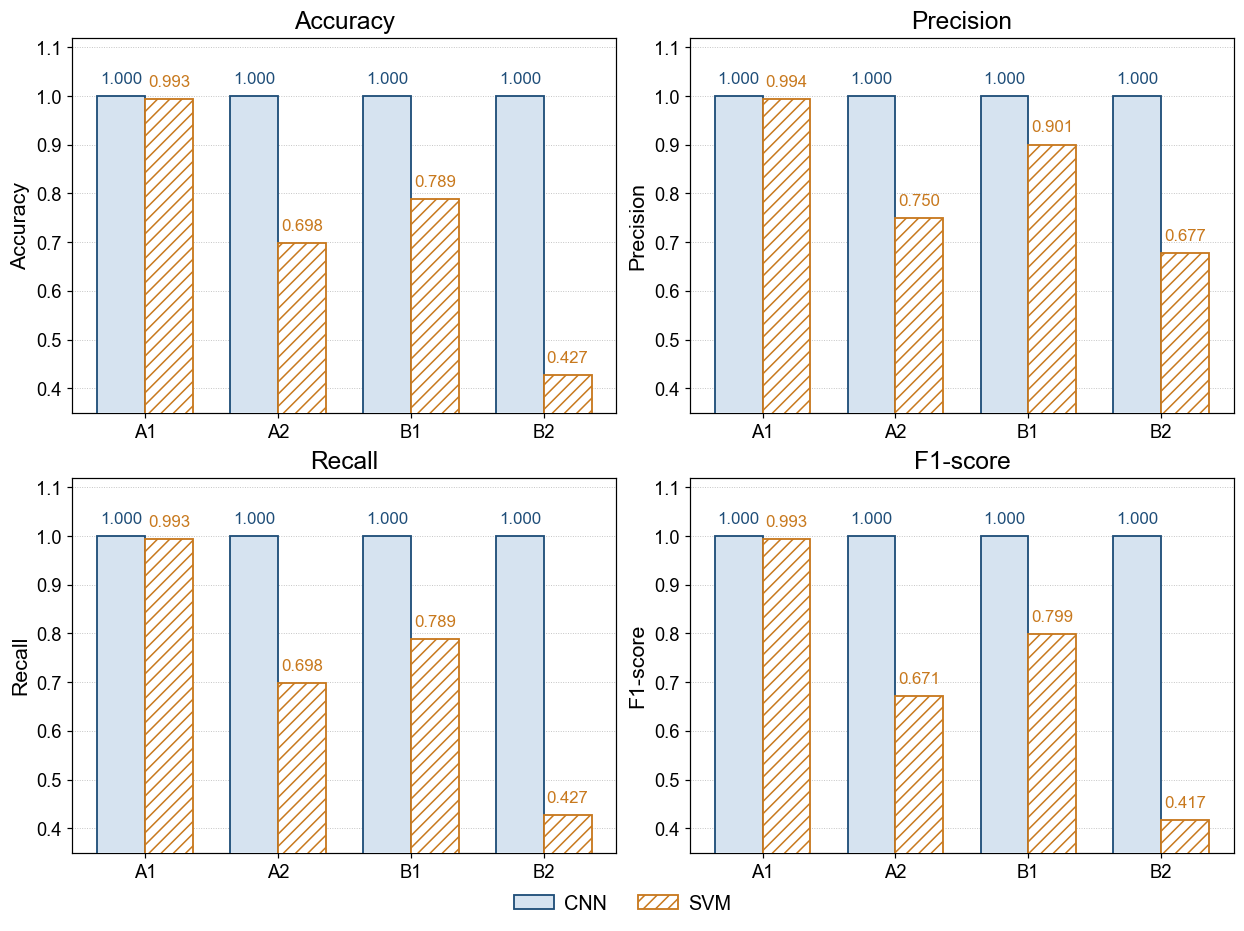

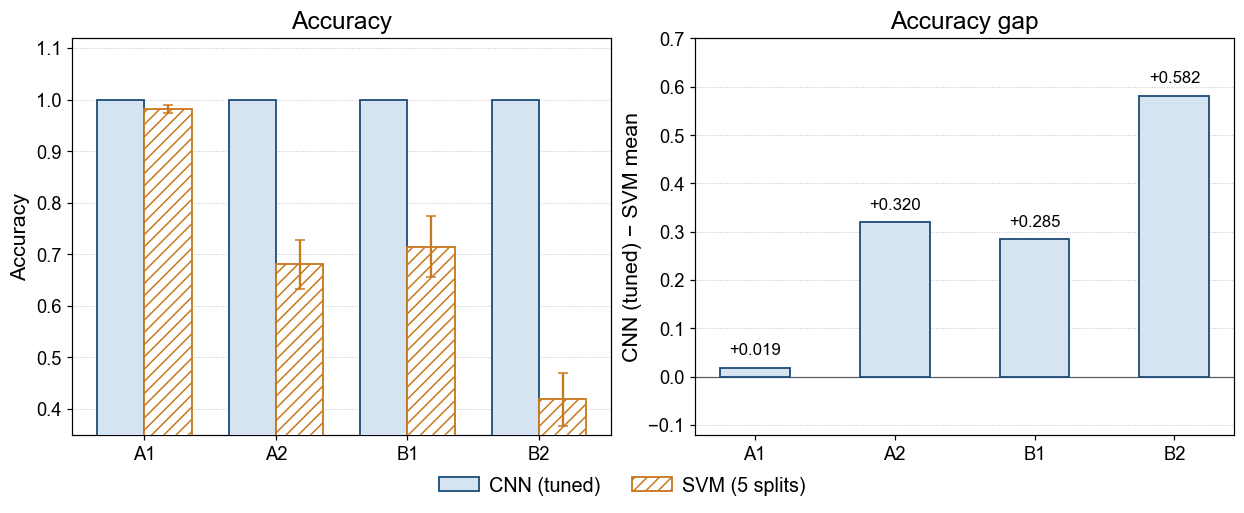

In [4]:
evals = [LABEL[ds] for ds in OOD]
x = np.arange(len(OOD))
width = 0.36
FILL = "#d6e3f0"
bar_kw = dict(linewidth=1.2, zorder=3)


def grouped_bars(ax, cnn_vals, svm_vals, ylabel):
    ax.bar(
        x - width / 2, cnn_vals, width,
        facecolor=FILL, edgecolor=NAVY, label="CNN", **bar_kw,
    )
    ax.bar(
        x + width / 2, svm_vals, width,
        facecolor="white", edgecolor=ACCENT, hatch="///", label="SVM", **bar_kw,
    )
    ax.set_xticks(x, evals)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0.35, 1.12)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    for xi, cv, sv in zip(x, cnn_vals, svm_vals):
        ax.text(xi - width / 2, cv + 0.02, f"{cv:.3f}", ha="center", va="bottom",
                fontsize=11, color=NAVY)
        ax.text(xi + width / 2, sv + 0.02, f"{sv:.3f}", ha="center", va="bottom",
                fontsize=11, color=ACCENT)


acc42 = seed_table("accuracy")
prec42 = seed_table("macro_precision")
rec42 = seed_table("macro_recall")
f142 = seed_table("macro_f1")
fig, axes = plt.subplots(2, 2, figsize=(11.2, 8.4), layout="constrained")
grouped_bars(axes[0, 0], acc42["CNN"], acc42["SVM"], "Accuracy")
grouped_bars(axes[0, 1], prec42["CNN"], prec42["SVM"], "Precision")
grouped_bars(axes[1, 0], rec42["CNN"], rec42["SVM"], "Recall")
grouped_bars(axes[1, 1], f142["CNN"], f142["SVM"], "F1-score")
axes[0, 0].set_title("Accuracy")
axes[0, 1].set_title("Precision")
axes[1, 0].set_title("Recall")
axes[1, 1].set_title("F1-score")
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///"),
    ],
    labels=["CNN", "SVM"],
    loc="outside lower center", ncol=2, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()

# CNN is one tuned run (no spread to show); SVM keeps its 5-split mean +/- std.
acc = cnn_vs_svm_spread("accuracy")
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), layout="constrained")
axes[0].bar(
    x - width / 2, acc["CNN (tuned)"], width,
    facecolor=FILL, edgecolor=NAVY, **bar_kw,
)
axes[0].bar(
    x + width / 2, acc["SVM mean"], width, yerr=acc["SVM std"], capsize=3,
    facecolor="white", edgecolor=ACCENT, hatch="///", ecolor=ACCENT, **bar_kw,
)
axes[0].set_xticks(x, evals)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.35, 1.12)
axes[0].set_title("Accuracy")

delta = acc["CNN vs SVM mean"]
axes[1].bar(x, delta, width=0.5, facecolor=FILL, edgecolor=NAVY, **bar_kw)
axes[1].axhline(0, color="0.35", linewidth=0.8)
axes[1].set_xticks(x, evals)
axes[1].set_ylabel("CNN (tuned) − SVM mean")
axes[1].set_title("Accuracy gap")
lo, hi = float(delta.min()), float(delta.max())
axes[1].set_ylim(min(lo, 0) - 0.12, max(hi, 0) + 0.12)
for xi, v in zip(x, delta):
    axes[1].text(xi, v + (0.02 if v >= 0 else -0.02), f"{v:+.3f}",
                 ha="center", va="bottom" if v >= 0 else "top", fontsize=11)

for ax in axes:
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///"),
    ],
    labels=["CNN (tuned)", "SVM (5 splits)"],
    loc="outside lower center", ncol=2, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()

## Per-class recall

Seed 42 only. A class is listed if either model is below 1.0. Sorted worst-first by min(CNN, SVM).

In [5]:
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    parts = body.split("_")
    if len(parts) >= 2 and parts[-1] in _QUAL:
        return f"{'_'.join(parts[:-1])} {_QUAL[parts[-1]]}"
    return body.replace("_", " ")


cnn_pc = pd.read_csv(CNN / "per_class_recall_seeds.csv")
svm_pc = pd.read_csv(SVM / "per_class_recall_seeds.csv")
mask = (cnn_pc.variant == VARIANT) & (cnn_pc.seed == SEED) & (cnn_pc.dataset.isin(OOD))
cnn_pc = cnn_pc.loc[mask, ["dataset", "class", "recall"]].rename(columns={"recall": "CNN"})
mask = (svm_pc.variant == VARIANT) & (svm_pc.seed == SEED) & (svm_pc.dataset.isin(OOD))
svm_pc = svm_pc.loc[mask, ["dataset", "class", "recall"]].rename(columns={"recall": "SVM"})
merged = cnn_pc.merge(svm_pc, on=["dataset", "class"], how="outer")
merged["Δ"] = merged["CNN"] - merged["SVM"]

for ds in OOD:
    sub = merged.loc[merged.dataset == ds].copy()
    sub = sub[(sub["CNN"] < 1.0) | (sub["SVM"] < 1.0)]
    sub["class"] = sub["class"].map(pretty_class)
    sub["worst"] = sub[["CNN", "SVM"]].min(axis=1)
    sub = sub.sort_values(["worst", "class"]).drop(columns=["dataset", "worst"])
    display(Markdown(f"**{LABEL[ds]}**"))
    if sub.empty:
        display(pd.DataFrame([{"note": "every class has recall 1.0 on both models"}]))
    else:
        display(sub.reset_index(drop=True).round(4))

**A1**

,class,CNN,SVM,Δ
0,G min,1.0,0.925,0.075
1,D min,1.0,0.950,0.050
2,B min,1.0,0.975,0.025
3,C maj,1.0,0.975,0.025
4,D# maj,1.0,0.975,0.025
5,E maj,1.0,0.975,0.025
6,G# dim,1.0,0.975,0.025


**A2**

,class,CNN,SVM,Δ
0,A dim,1.0,0.000,1.000
1,A maj,1.0,0.000,1.000
2,A# dim,1.0,0.000,1.000
3,B dim,1.0,0.000,1.000
4,B min,1.0,0.000,1.000
5,G min,1.0,0.000,1.000
6,B maj,1.0,0.150,0.850
7,F# dim,1.0,0.150,0.850
8,A# min,1.0,0.225,0.775
9,A# maj,1.0,0.300,0.700


**B1**

,class,CNN,SVM,Δ
0,D min,1.0,0.000,1.000
1,D# min,1.0,0.000,1.000
2,D maj,1.0,0.075,0.925
3,D# maj,1.0,0.150,0.850
4,F# dim,1.0,0.250,0.750
5,B min,1.0,0.350,0.650
6,F maj,1.0,0.575,0.425
7,F min,1.0,0.625,0.375
8,G min,1.0,0.725,0.275
9,E maj,1.0,0.800,0.200


**B2**

,class,CNN,SVM,Δ
0,A dim,1.0,0.000,1.000
1,A maj,1.0,0.000,1.000
2,A# dim,1.0,0.000,1.000
3,A# min,1.0,0.000,1.000
4,B dim,1.0,0.000,1.000
5,B maj,1.0,0.000,1.000
6,B min,1.0,0.000,1.000
7,F# dim,1.0,0.000,1.000
8,G min,1.0,0.000,1.000
9,A# maj,1.0,0.025,0.975


## Combined confusion

Clean seed 42. Count matrices for A1, A2, B1, and B2 added cellwise. Vivo omitted. Zeros annotated.

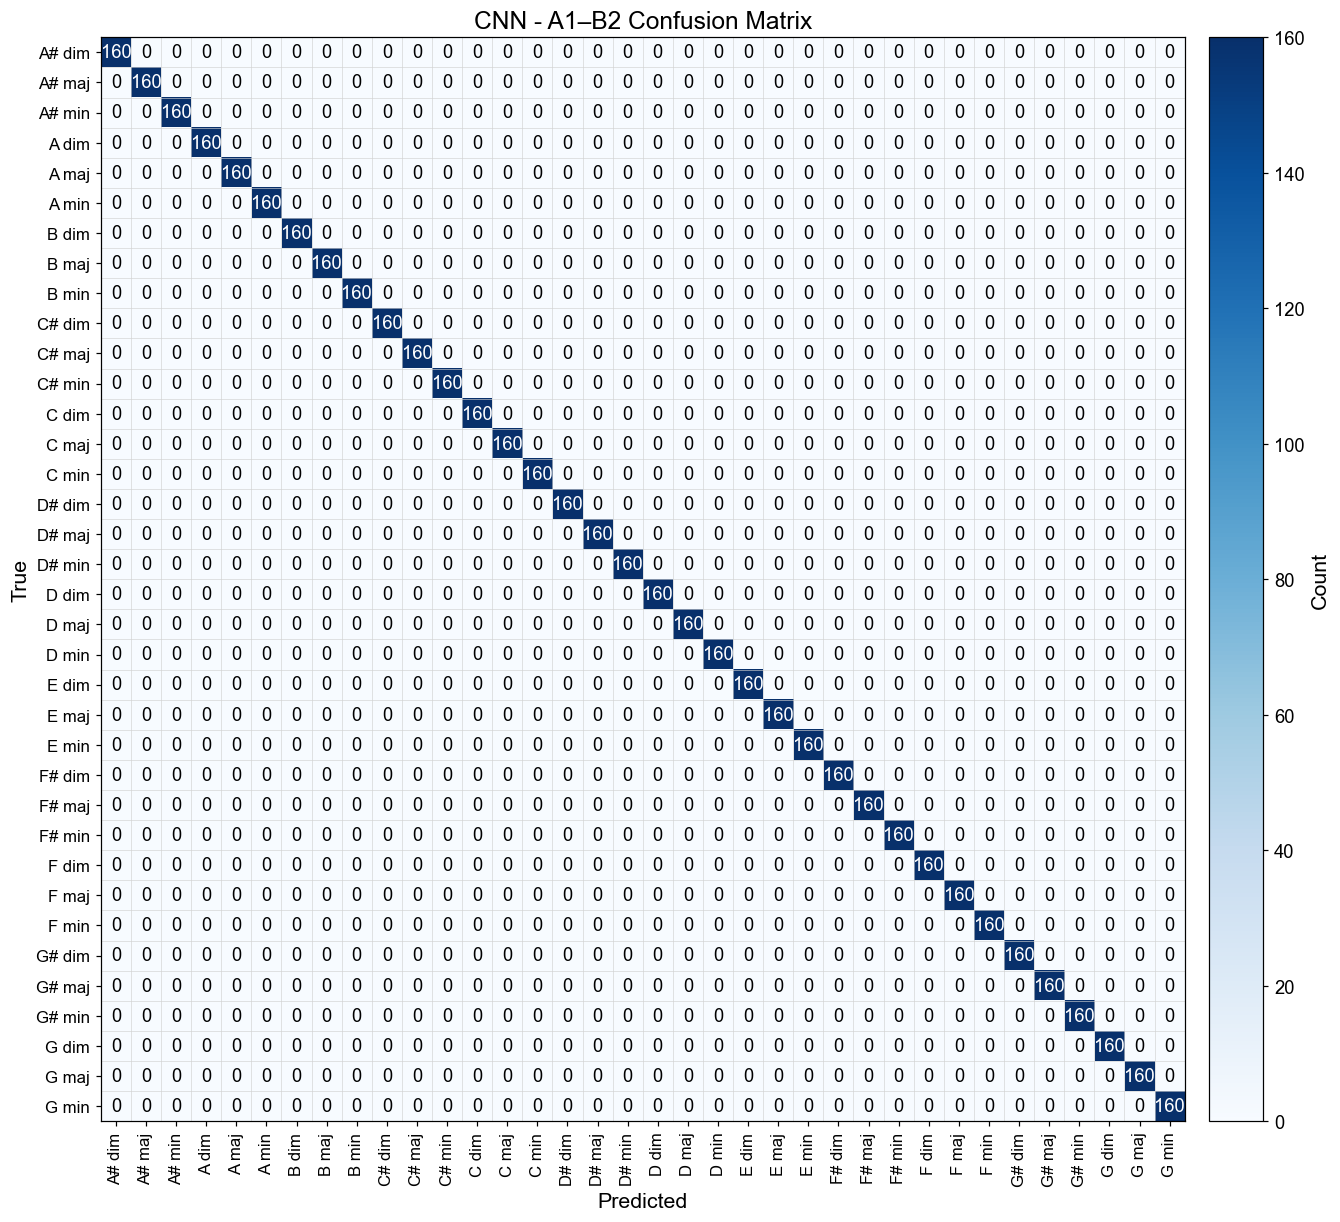

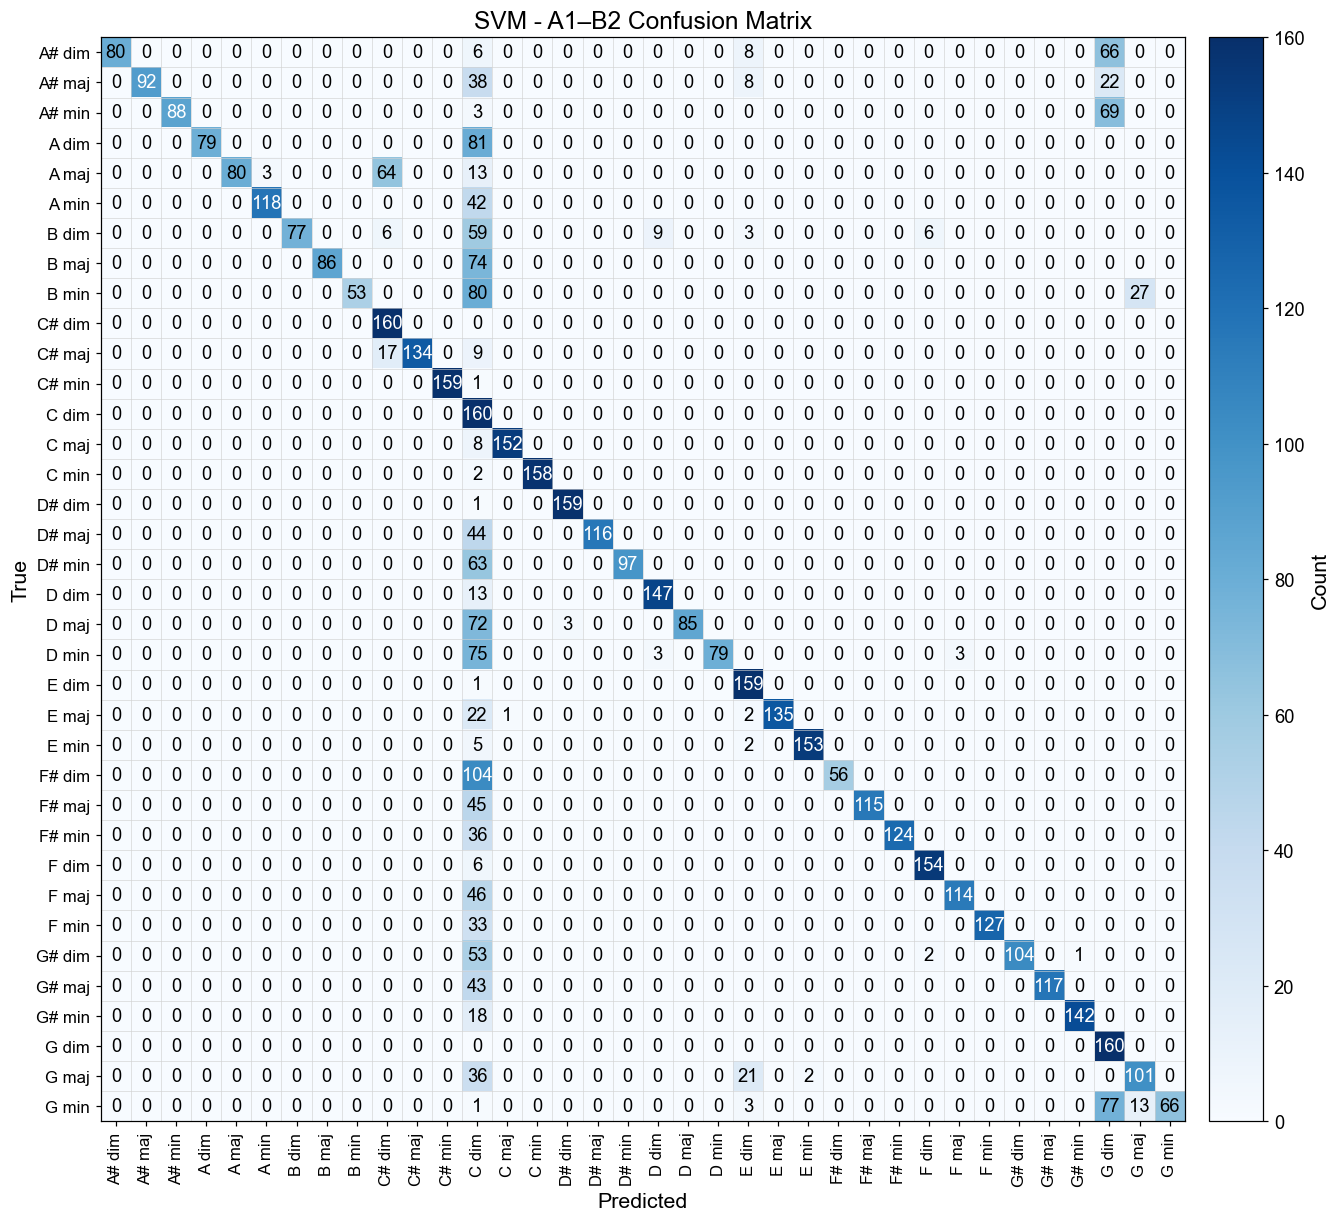

**A1–B2 combined**, seed 42

,model,accuracy,precision,recall,f1-score,n
0,CNN,1.0000,1.000,1.0000,1.0000,5760
1,SVM,0.7267,0.929,0.7267,0.7753,5760


In [6]:
from matplotlib.ticker import MaxNLocator

CNN_CM = CNN / "confusion"
SVM_CM = SVM / "confusion"
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    parts = body.split("_")
    if len(parts) >= 2 and parts[-1] in _QUAL:
        return f"{'_'.join(parts[:-1])} {_QUAL[parts[-1]]}"
    return body.replace("_", " ")


def load_recorded_cm(root: Path, dataset: str) -> pd.DataFrame:
    path = root / f"{dataset}_{VARIANT}_seed{SEED}.csv"
    assert path.is_file(), path
    return pd.read_csv(path, index_col=0)


def draw_cm(ax, mat, labels, title):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(mat[i, j])
            ax.text(
                j, i, str(val), ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


def metrics_from_cm(mat: np.ndarray, names: list[str]):
    mat = np.asarray(mat, dtype=float)
    support = mat.sum(axis=1)
    pred_n = mat.sum(axis=0)
    tp = np.diag(mat)
    n = float(mat.sum())
    precision = np.divide(tp, pred_n, out=np.zeros_like(tp), where=pred_n > 0)
    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    denom = precision + recall
    f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    return {
        "accuracy": float(tp.sum() / n) if n else 0.0,
        "precision": float(np.mean(precision)),
        "recall": float(np.mean(recall)),
        "f1-score": float(np.mean(f1)),
        "n": int(n),
    }


names = list(load_recorded_cm(CNN_CM, OOD[0]).index)
labels = [pretty_class(c) for c in names]
rows = []
for model, root in (("CNN", CNN_CM), ("SVM", SVM_CM)):
    mats = [load_recorded_cm(root, ds).loc[names, names].to_numpy(dtype=float) for ds in OOD]
    mat = np.sum(mats, axis=0)
    pd.DataFrame(mat, index=names, columns=names).to_csv(
        root / f"a1-b2_{VARIANT}_seed{SEED}.csv"
    )
    rows.append({"model": model, **metrics_from_cm(mat, names)})
    fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
    im = draw_cm(ax, mat, labels, f"{model} - A1–B2 Confusion Matrix")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Count")
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

display(Markdown("**A1–B2 combined**, seed 42"))
display(pd.DataFrame(rows).round(4))


## Overlay

Eval-only noise / room IR / mic IR on the same four recorded sets, **clean seed 42 only**. Tax is recorded accuracy minus overlay accuracy.

In [7]:
OVERLAYS = ["noise", "rir", "dir"]
OVERLAY_LABEL = {"noise": "noise", "rir": "room IR", "dir": "mic IR"}

cnn_ov = pd.read_csv(CNN / "overlay_seeds.csv")
svm_ov = pd.read_csv(SVM / "overlay_seeds.csv")
cnn_ov = cnn_ov[(cnn_ov.variant == VARIANT) & (cnn_ov.seed == SEED) & (cnn_ov.dataset.isin(OOD))].copy()
svm_ov = svm_ov[(svm_ov.variant == VARIANT) & (svm_ov.seed == SEED) & (svm_ov.dataset.isin(OOD))].copy()
assert set(OVERLAYS) <= set(cnn_ov.overlay) and set(OVERLAYS) <= set(svm_ov.overlay)


def overlay_accuracy() -> pd.DataFrame:
    rows = []
    for ds in OOD:
        row = {"evaluation": LABEL[ds]}
        row["CNN"] = float(cnn.loc[(cnn.seed == SEED) & (cnn.dataset == ds), "accuracy"].iloc[0])
        row["SVM"] = float(svm.loc[(svm.seed == SEED) & (svm.dataset == ds), "accuracy"].iloc[0])
        for ov in OVERLAYS:
            c = float(cnn_ov.loc[(cnn_ov.dataset == ds) & (cnn_ov.overlay == ov), "accuracy"].iloc[0])
            s = float(svm_ov.loc[(svm_ov.dataset == ds) & (svm_ov.overlay == ov), "accuracy"].iloc[0])
            row[f"CNN {OVERLAY_LABEL[ov]}"] = c
            row[f"SVM {OVERLAY_LABEL[ov]}"] = s
        rows.append(row)
    return pd.DataFrame(rows)


def overlay_tax() -> pd.DataFrame:
    acc = overlay_accuracy()
    rows = []
    for ov in OVERLAYS:
        lab = OVERLAY_LABEL[ov]
        for _, r in acc.iterrows():
            c_tax = r["CNN"] - r[f"CNN {lab}"]
            s_tax = r["SVM"] - r[f"SVM {lab}"]
            rows.append({
                "overlay": lab,
                "evaluation": r["evaluation"],
                "CNN tax": float(c_tax),
                "SVM tax": float(s_tax),
                "Δ tax": float(c_tax - s_tax),
            })
    return pd.DataFrame(rows)


display(Markdown("**Seed 42 accuracy** — recorded vs each overlay"))
display(overlay_accuracy().round(4))
display(Markdown("**Tax (recorded − overlay), seed 42**"))
display(overlay_tax().round(4))

**Seed 42 accuracy** — recorded vs each overlay

,evaluation,CNN,SVM,CNN noise,SVM noise,CNN room IR,SVM room IR,CNN mic IR,SVM mic IR
0,A1,1.0,0.9931,0.9958,0.5861,1.0000,0.9347,1.0,0.9299
1,A2,1.0,0.6979,0.9979,0.2688,0.9993,0.8299,1.0,0.8535
2,B1,1.0,0.7889,0.9993,0.3243,0.9986,0.8625,1.0,0.8562
3,B2,1.0,0.4271,0.9965,0.1757,0.9993,0.7174,1.0,0.7396


**Tax (recorded − overlay), seed 42**

,overlay,evaluation,CNN tax,SVM tax,Δ tax
0,noise,A1,0.0042,0.4069,-0.4028
1,noise,A2,0.0021,0.4292,-0.4271
2,noise,B1,0.0007,0.4646,-0.4639
3,noise,B2,0.0035,0.2514,-0.2479
4,room IR,A1,0.0000,0.0583,-0.0583
5,room IR,A2,0.0007,-0.1319,0.1326
6,room IR,B1,0.0014,-0.0736,0.0750
7,room IR,B2,0.0007,-0.2903,0.2910
8,mic IR,A1,0.0000,0.0632,-0.0632
9,mic IR,A2,0.0000,-0.1556,0.1556


## Overlay tax

Points of accuracy removed by each overlay. Outlined bars, legend outside the axes.

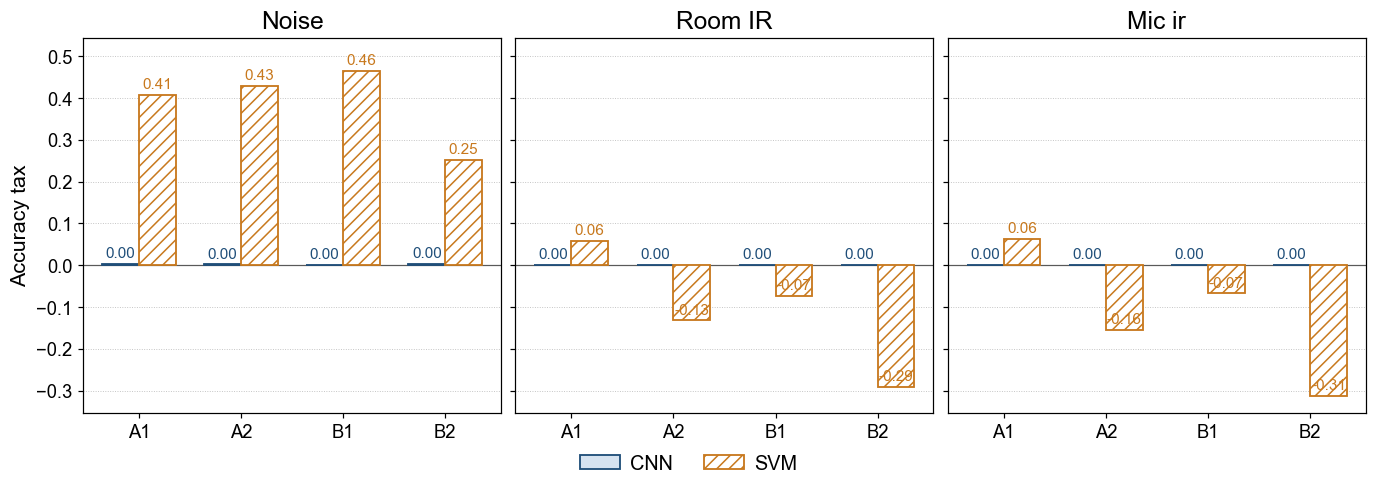

In [8]:
FILL = "#d6e3f0"
evals = [LABEL[ds] for ds in OOD]
x = np.arange(len(OOD))
width = 0.36
tax = overlay_tax()

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.4), layout="constrained", sharey=True)
for ax, ov in zip(axes, OVERLAYS):
    sub = tax.loc[tax.overlay == OVERLAY_LABEL[ov]]
    ax.bar(
        x - width / 2, sub["CNN tax"], width,
        facecolor=FILL, edgecolor=NAVY, linewidth=1.2, zorder=3,
    )
    ax.bar(
        x + width / 2, sub["SVM tax"], width,
        facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///", zorder=3,
    )
    ax.set_xticks(x, evals)
    ax.set_title("Room IR" if ov == "rir" else OVERLAY_LABEL[ov].capitalize())
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    ax.axhline(0, color="0.35", linewidth=0.8)
    for xi, cv, sv in zip(x, sub["CNN tax"], sub["SVM tax"]):
        ax.text(xi - width / 2, cv + 0.008, f"{cv:.2f}", ha="center", va="bottom",
                fontsize=10, color=NAVY)
        ax.text(xi + width / 2, sv + 0.008, f"{sv:.2f}", ha="center", va="bottom",
                fontsize=10, color=ACCENT)
axes[0].set_ylabel("Accuracy tax")
vals = tax[["CNN tax", "SVM tax"]].to_numpy()
axes[0].set_ylim(min(0.0, float(vals.min()) - 0.04), float(vals.max()) + 0.08)
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///"),
    ],
    labels=["CNN", "SVM"],
    loc="outside lower center", ncol=2, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()

## Noise classification

Clean seed 42. Macro metrics from the confusion matrices, then the matrices themselves (zeros annotated). Per-class rows are only classes with accuracy below 1.0.

In [9]:
from matplotlib.ticker import MaxNLocator

CNN_CM = CNN / "confusion"
SVM_CM = SVM / "confusion"
OVERLAY_NAME = "noise"
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    parts = body.split("_")
    if len(parts) >= 2 and parts[-1] in _QUAL:
        return f"{'_'.join(parts[:-1])} {_QUAL[parts[-1]]}"
    return body.replace("_", " ")


def load_overlay_cm(root, dataset: str) -> pd.DataFrame:
    path = root / f"{dataset}_{OVERLAY_NAME}_{VARIANT}_seed{SEED}.csv"
    assert path.is_file(), path
    return pd.read_csv(path, index_col=0)


def metrics_from_cm(mat: np.ndarray, names: list[str]):
    mat = np.asarray(mat, dtype=float)
    support = mat.sum(axis=1)
    pred_n = mat.sum(axis=0)
    tp = np.diag(mat)
    n = float(mat.sum())
    precision = np.divide(tp, pred_n, out=np.zeros_like(tp), where=pred_n > 0)
    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    denom = precision + recall
    f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    acc_cls = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    per_class = pd.DataFrame(
        {
            "class": [pretty_class(c) for c in names],
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "accuracy": acc_cls,
            "support": support.astype(int),
        }
    )
    summary = {
        "accuracy": float(tp.sum() / n) if n else 0.0,
        "precision": float(np.mean(precision)),
        "recall": float(np.mean(recall)),
        "f1-score": float(np.mean(f1)),
    }
    return per_class, summary


def draw_cm(ax, mat, labels, title):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(mat[i, j])
            ax.text(
                j, i, str(val), ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


names = list(load_overlay_cm(CNN_CM, OOD[0]).index)
rows = []
PER_CLASS = {}
for model, root in (("CNN", CNN_CM), ("SVM", SVM_CM)):
    for ds in OOD:
        cm = load_overlay_cm(root, ds).loc[names, names].to_numpy(dtype=float)
        per_class, summary = metrics_from_cm(cm, names)
        PER_CLASS[(model, ds)] = per_class
        rows.append({"model": model, "evaluation": LABEL[ds], **summary})

display(Markdown("**Noise — macro metrics**"))
display(pd.DataFrame(rows).round(4))

cols = ["class", "precision", "recall", "f1-score", "accuracy", "support"]
for model, ds in PER_CLASS:
    sub = PER_CLASS[(model, ds)]
    bad = sub.loc[sub.accuracy < 1.0, cols].sort_values(["accuracy", "class"])
    display(Markdown(f"**{model} — {LABEL[ds]} noise**, imperfect classes"))
    if bad.empty:
        display(pd.DataFrame([{"note": "every class has accuracy 1.0"}]))
    else:
        display(bad.reset_index(drop=True).round(4))

**Noise — macro metrics**

,model,evaluation,accuracy,precision,recall,f1-score
0,CNN,A1,0.9958,0.9959,0.9958,0.9958
1,CNN,A2,0.9979,0.9979,0.9979,0.9979
2,CNN,B1,0.9993,0.9993,0.9993,0.9993
3,CNN,B2,0.9965,0.9966,0.9965,0.9965
4,SVM,A1,0.5861,0.8858,0.5861,0.6402
5,SVM,A2,0.2688,0.5856,0.2688,0.2611
6,SVM,B1,0.3243,0.6798,0.3243,0.3570
7,SVM,B2,0.1757,0.3830,0.1757,0.1541


**CNN — A1 noise**, imperfect classes

,class,precision,recall,f1-score,accuracy,support
0,G# min,0.9744,0.950,0.9620,0.950,40
1,A# dim,1.0000,0.975,0.9873,0.975,40
2,A# maj,1.0000,0.975,0.9873,0.975,40
3,E maj,1.0000,0.975,0.9873,0.975,40
4,F# dim,1.0000,0.975,0.9873,0.975,40


**CNN — A2 noise**, imperfect classes

...

,class,precision,recall,f1-score,accuracy,support
0,A dim,0.0000,0.000,0.0000,0.000,40
1,A maj,0.0000,0.000,0.0000,0.000,40
2,A# dim,0.0000,0.000,0.0000,0.000,40
3,A# maj,0.0000,0.000,0.0000,0.000,40
4,A# min,0.0000,0.000,0.0000,0.000,40
5,B dim,0.0000,0.000,0.0000,0.000,40
6,B maj,0.0000,0.000,0.0000,0.000,40
7,B min,0.0000,0.000,0.0000,0.000,40
8,D# min,0.0000,0.000,0.0000,0.000,40
9,G maj,0.0000,0.000,0.0000,0.000,40


**SVM — B1 noise**, imperfect classes

,class,precision,recall,f1-score,accuracy,support
0,B min,0.0000,0.000,0.0000,0.000,40
1,D maj,0.0000,0.000,0.0000,0.000,40
2,D min,0.0000,0.000,0.0000,0.000,40
3,D# maj,0.0000,0.000,0.0000,0.000,40
4,D# min,0.0000,0.000,0.0000,0.000,40
5,F# dim,0.0000,0.000,0.0000,0.000,40
6,G min,0.0000,0.000,0.0000,0.000,40
7,F# min,1.0000,0.050,0.0952,0.050,40
8,F# maj,1.0000,0.075,0.1395,0.075,40
9,B dim,1.0000,0.100,0.1818,0.100,40


**SVM — B2 noise**, imperfect classes

,class,precision,recall,f1-score,accuracy,support
0,A dim,0.0000,0.000,0.0000,0.000,40
1,A maj,0.0000,0.000,0.0000,0.000,40
2,A# dim,0.0000,0.000,0.0000,0.000,40
3,A# maj,0.0000,0.000,0.0000,0.000,40
4,A# min,0.0000,0.000,0.0000,0.000,40
5,B dim,0.0000,0.000,0.0000,0.000,40
6,B maj,0.0000,0.000,0.0000,0.000,40
7,B min,0.0000,0.000,0.0000,0.000,40
8,D maj,0.0000,0.000,0.0000,0.000,40
9,D min,0.0000,0.000,0.0000,0.000,40


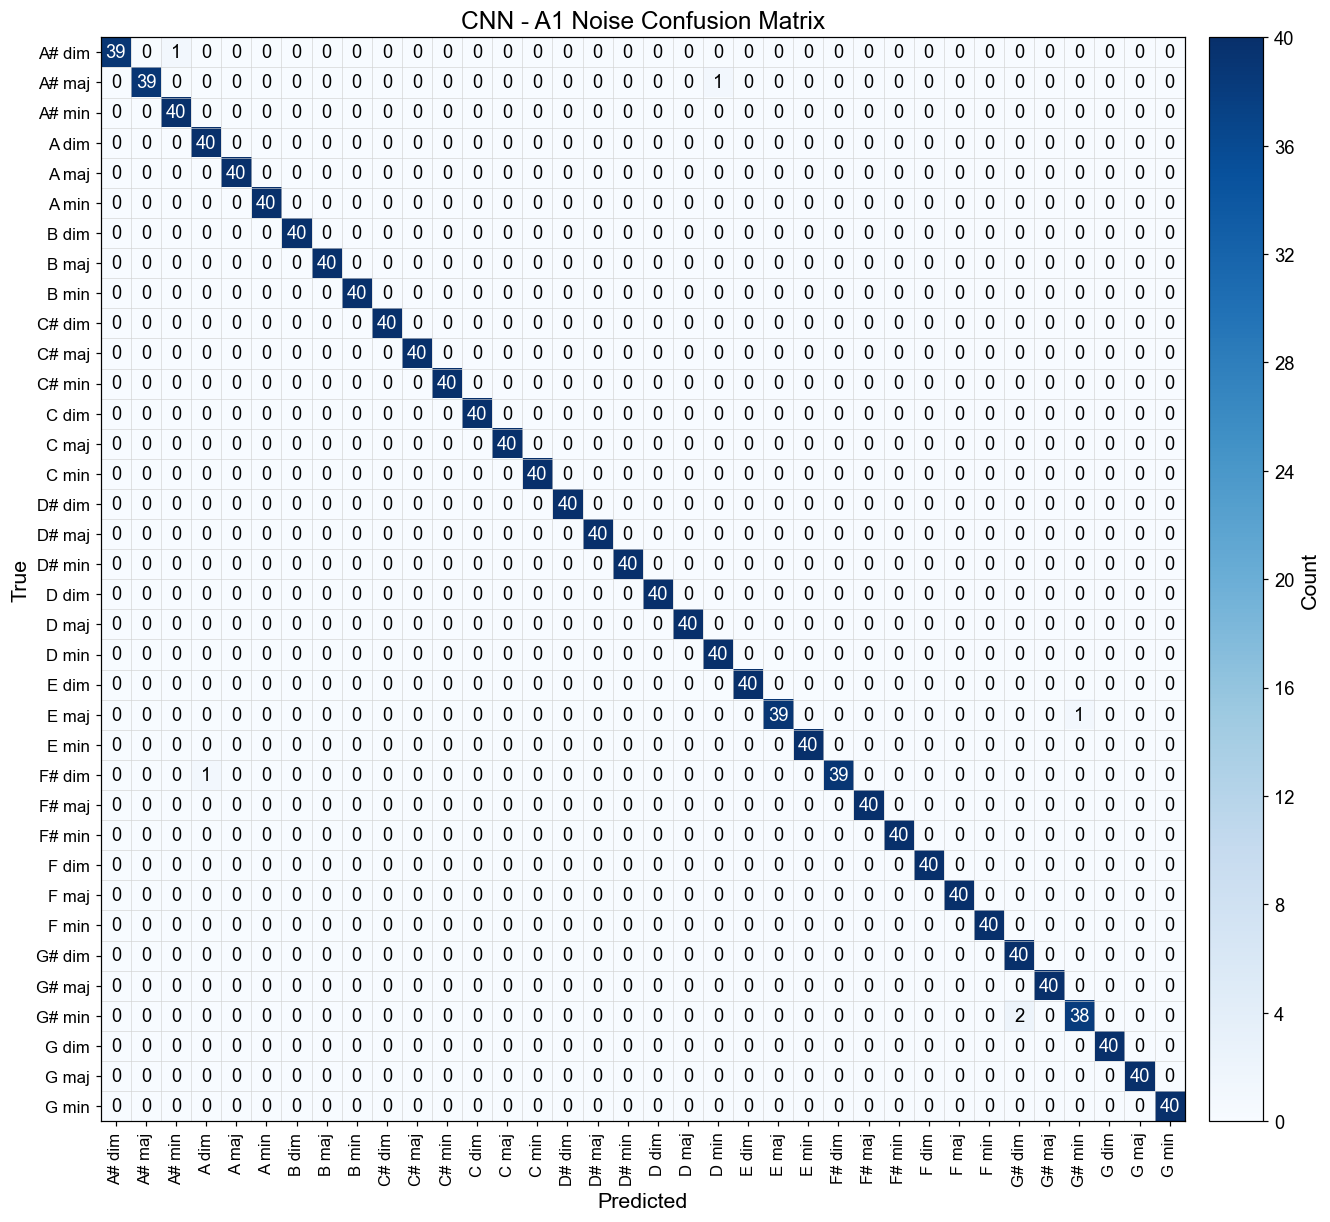

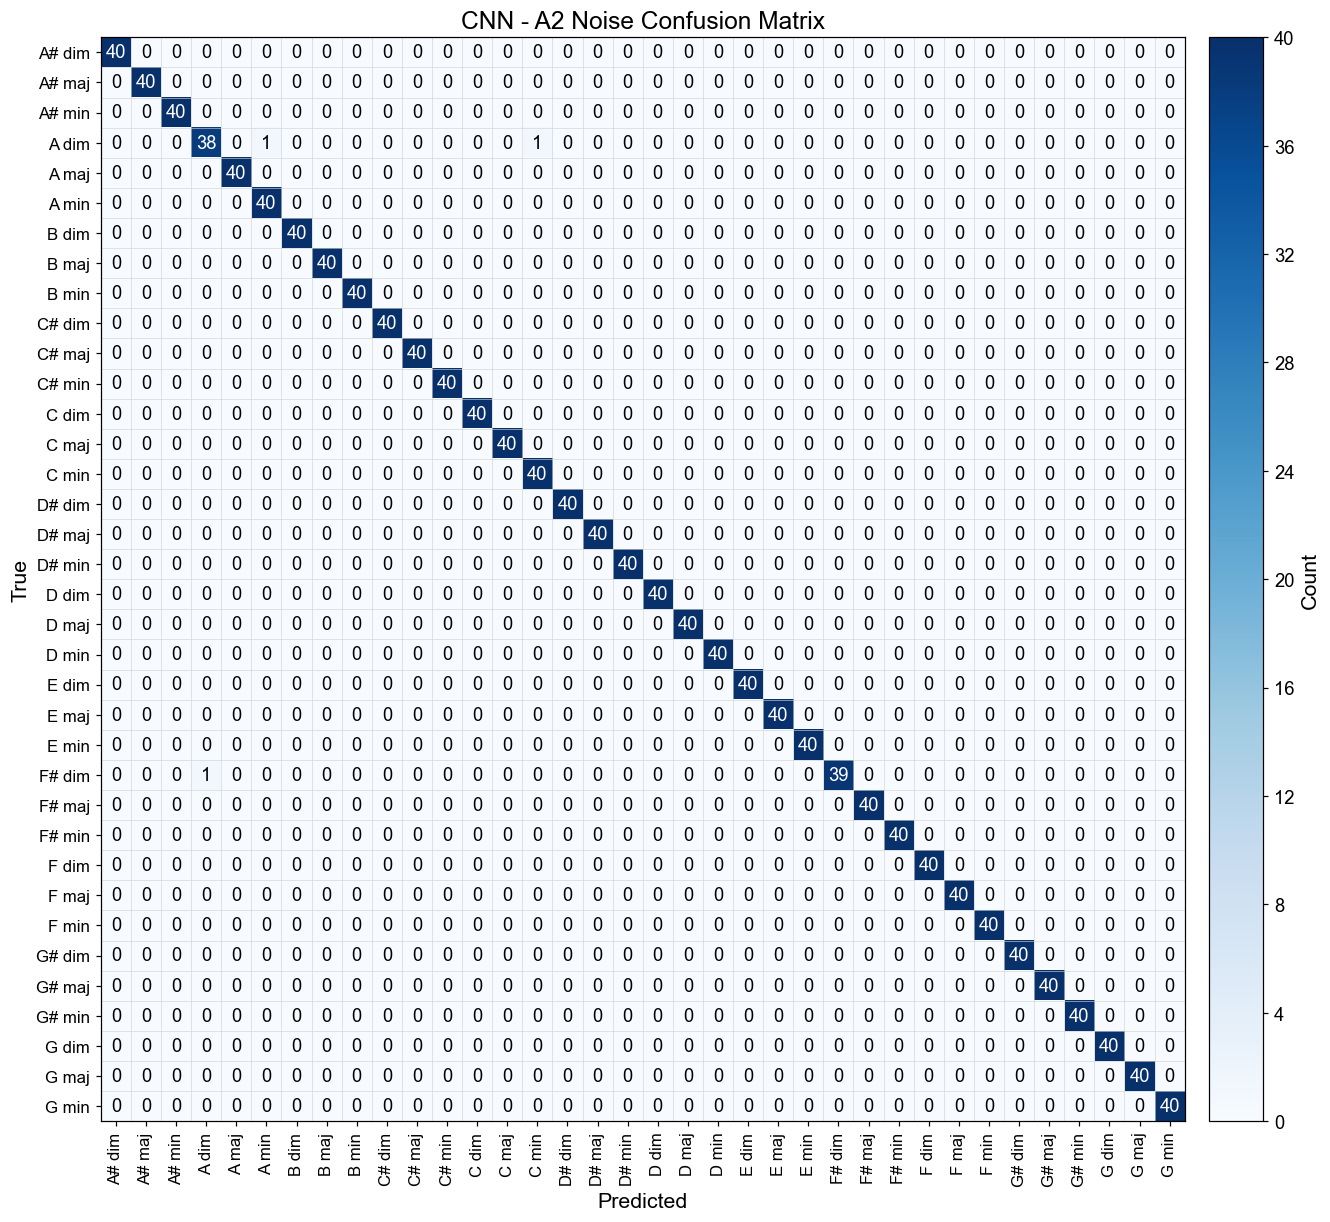

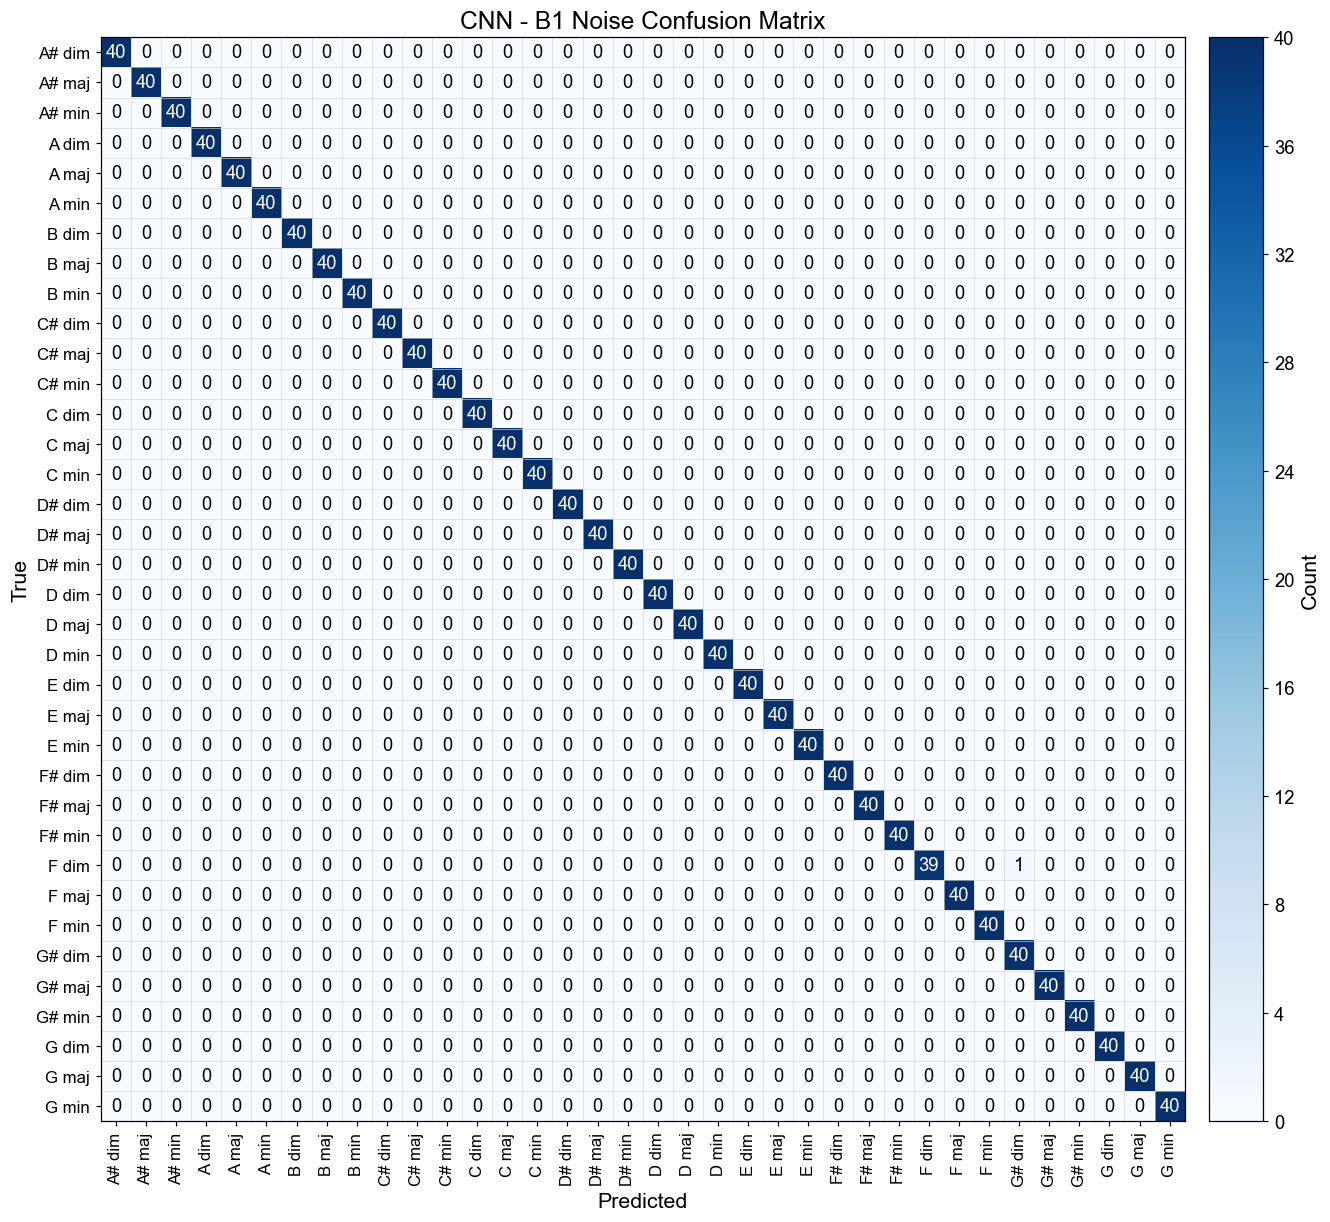

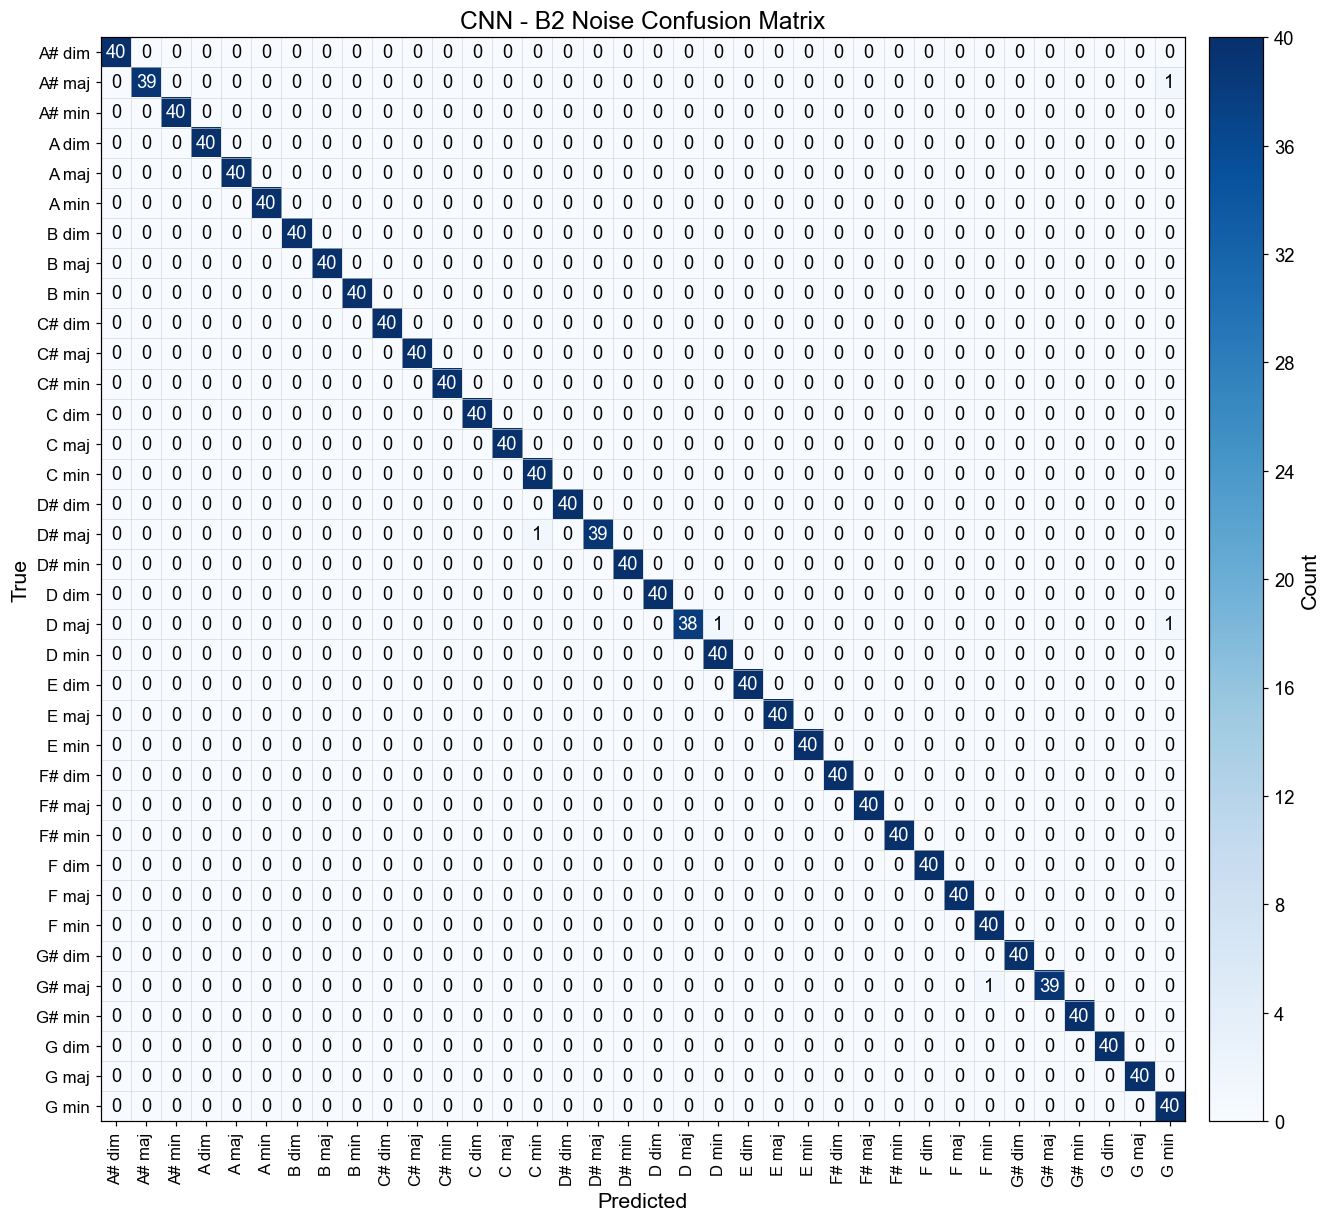

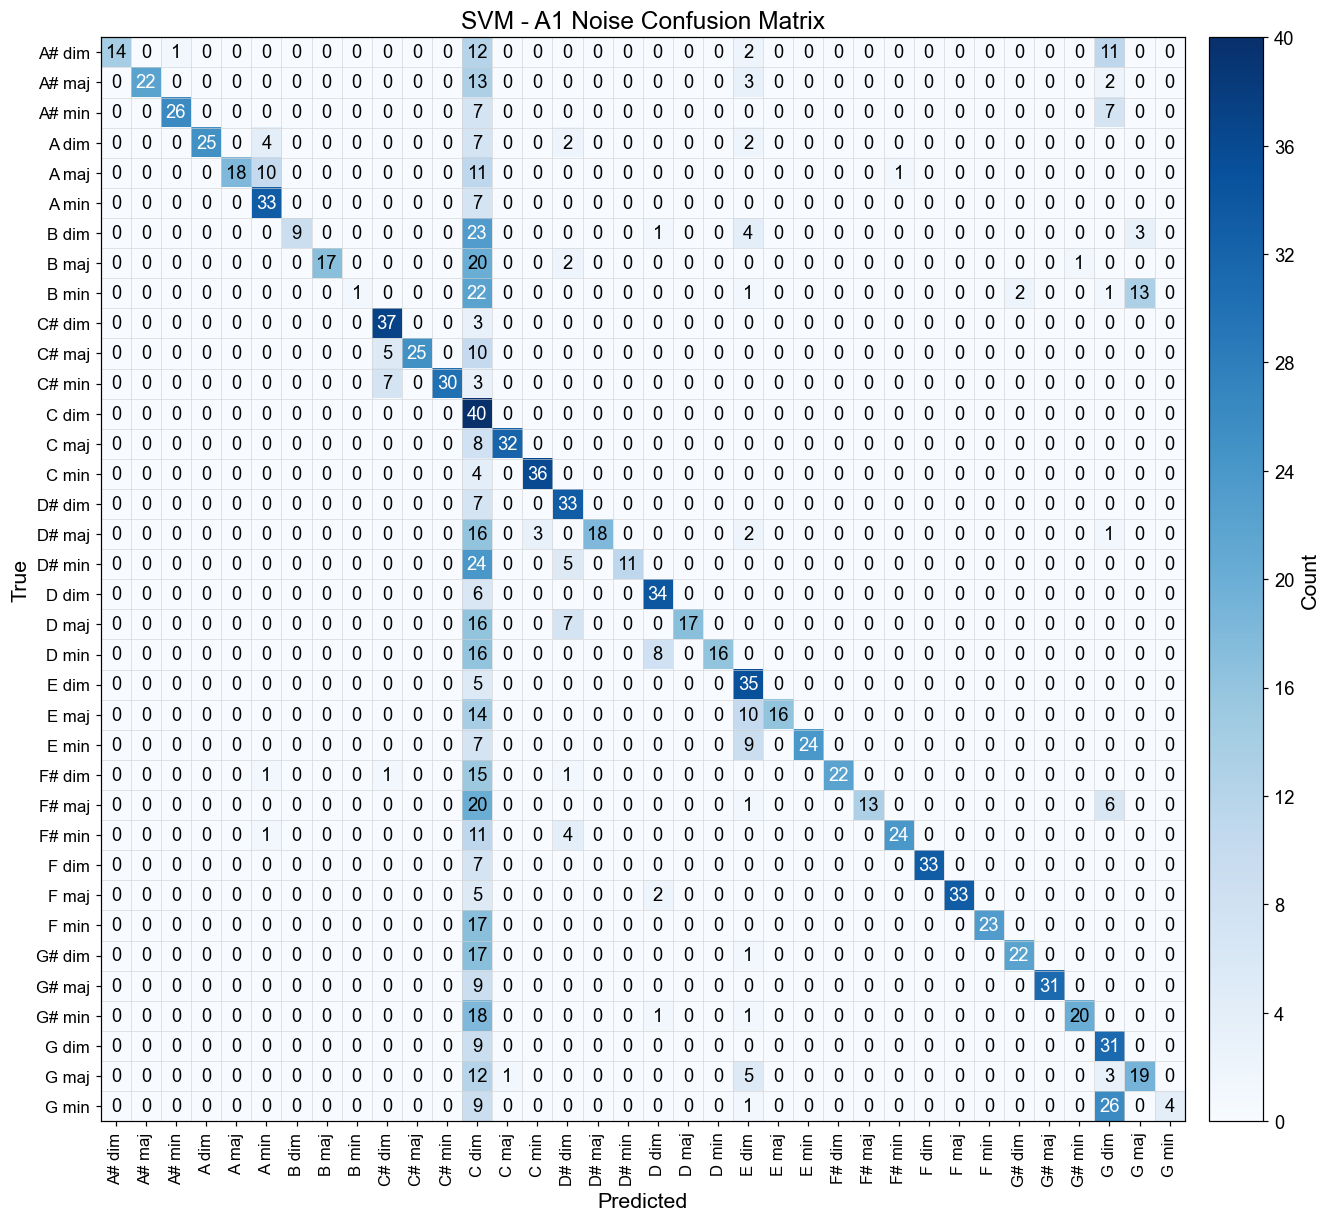

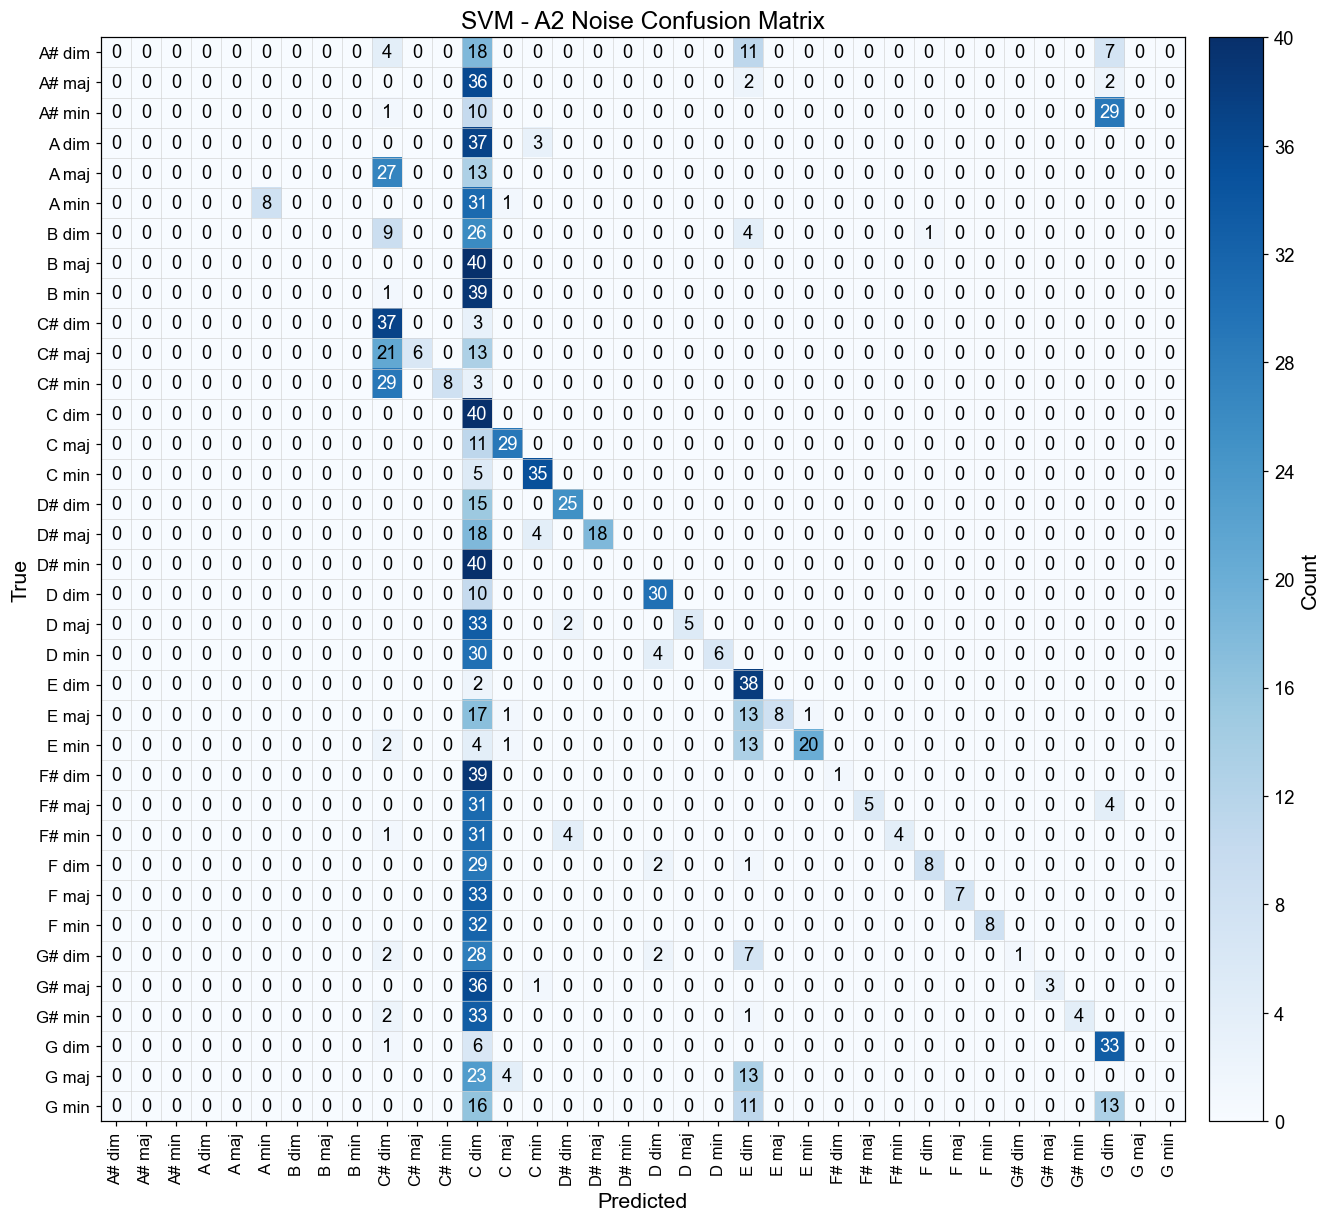

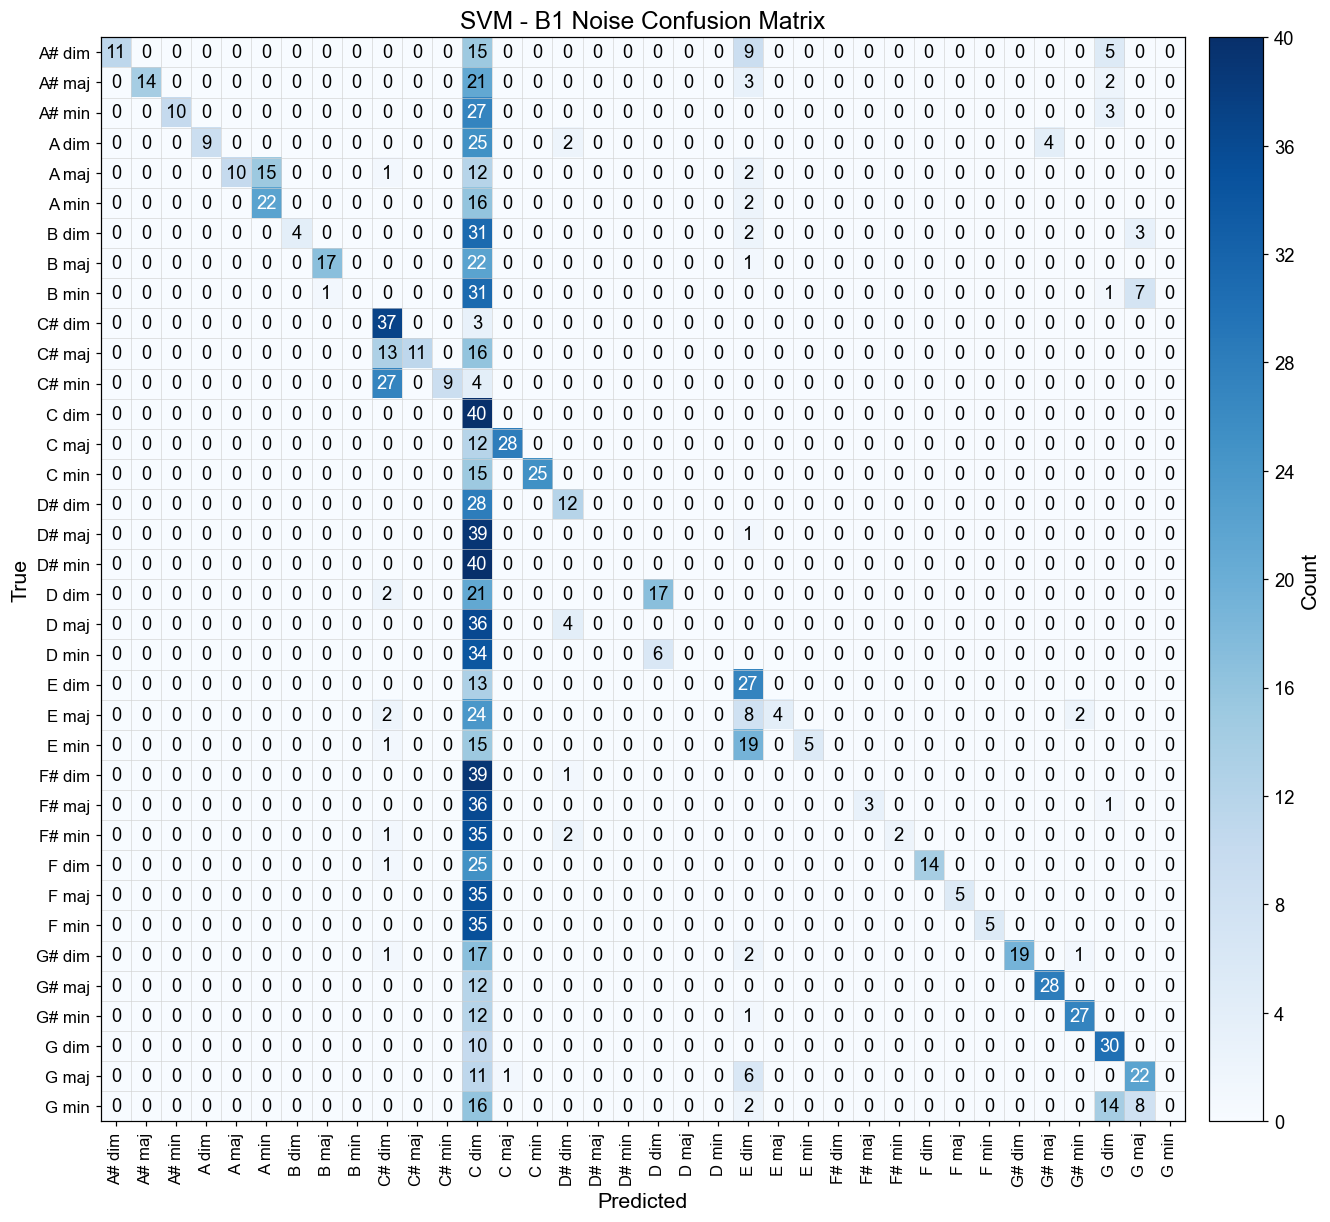

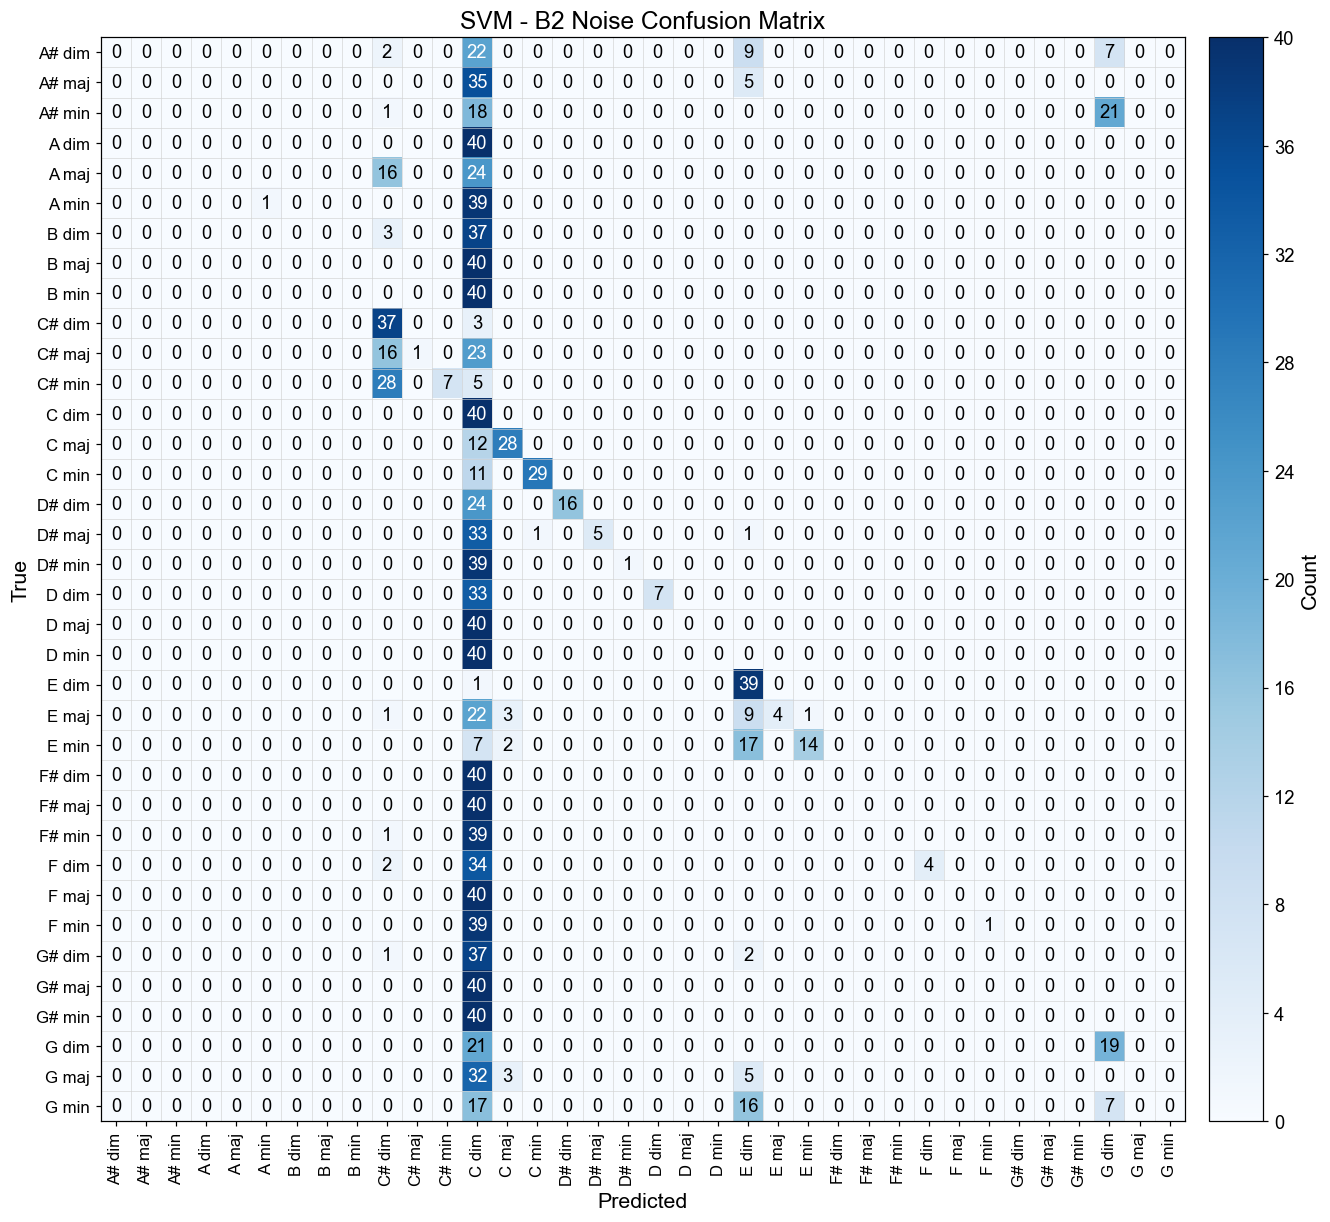

In [10]:
labels = [pretty_class(c) for c in names]
for model, root in (("CNN", CNN_CM), ("SVM", SVM_CM)):
    for ds in OOD:
        mat = load_overlay_cm(root, ds).loc[names, names].to_numpy(dtype=float)
        fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
        im = draw_cm(ax, mat, labels, f"{model} - {LABEL[ds]} Noise Confusion Matrix")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Count")
        cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        plt.show()

## Classes most affected by noise

Drop is recorded recall minus noise recall on clean seed 42. A class can already be dead on the recorded set (drop near 0, noise recall still 0); those show up in the **lowest noise recall** tables, not only in the drop ranking.

In [11]:
def load_recall(root: Path, overlay: bool) -> pd.DataFrame:
    if overlay:
        df = pd.read_csv(root / "overlay_per_class_recall.csv")
        df = df[(df.variant == VARIANT) & (df.seed == SEED) & (df.overlay == "noise")]
    else:
        df = pd.read_csv(root / "per_class_recall_seeds.csv")
        df = df[(df.variant == VARIANT) & (df.seed == SEED)]
    return df.loc[df.dataset.isin(OOD), ["dataset", "class", "recall"]]


def with_drop(base: pd.DataFrame, noise: pd.DataFrame, model: str) -> pd.DataFrame:
    m = base.merge(noise, on=["dataset", "class"], suffixes=("_rec", "_noise"))
    m["drop"] = m["recall_rec"] - m["recall_noise"]
    m["model"] = model
    m["evaluation"] = m.dataset.map(LABEL)
    m["class"] = m["class"].map(pretty_class)
    return m


cnn_drop = with_drop(
    load_recall(CNN, False), load_recall(CNN, True), "CNN"
)
svm_drop = with_drop(
    load_recall(SVM, False), load_recall(SVM, True), "SVM"
)


def top_drop(df: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    return (
        df.sort_values(["drop", "recall_noise", "class"], ascending=[False, True, True])
        .head(n)[["class", "recall_rec", "recall_noise", "drop"]]
        .reset_index(drop=True)
    )


for ds in OOD:
    display(Markdown(f"**{LABEL[ds]}** — largest recall drop"))
    left = top_drop(cnn_drop.loc[cnn_drop.dataset == ds]).add_prefix("CNN ")
    right = top_drop(svm_drop.loc[svm_drop.dataset == ds]).add_prefix("SVM ")
    display(pd.concat([left, right], axis=1).round(3))


def overall(df: pd.DataFrame) -> pd.DataFrame:
    g = (
        df.groupby("class", as_index=False)
        .agg(
            recorded=("recall_rec", "mean"),
            noise=("recall_noise", "mean"),
            drop=("drop", "mean"),
            sets_hit=("drop", lambda s: int((s > 0).sum())),
        )
        .sort_values(["drop", "noise", "class"], ascending=[False, True, True])
    )
    return g.reset_index(drop=True)


cnn_all = overall(cnn_drop)
svm_all = overall(svm_drop)
display(Markdown("**Overall** — mean drop across A1–B2"))
display(pd.concat(
    [
        cnn_all.head(10).add_prefix("CNN "),
        svm_all.head(10).add_prefix("SVM "),
    ],
    axis=1,
).round(3))

display(Markdown("**Overall** — lowest noise recall (includes classes already dead on recorded)"))
cnn_low = cnn_all.sort_values(["noise", "class"]).head(10).reset_index(drop=True)
svm_low = svm_all.sort_values(["noise", "class"]).head(10).reset_index(drop=True)
display(pd.concat(
    [
        cnn_low[["class", "recorded", "noise", "drop"]].add_prefix("CNN "),
        svm_low[["class", "recorded", "noise", "drop"]].add_prefix("SVM "),
    ],
    axis=1,
).round(3))

def quality_row(df: pd.DataFrame, model: str) -> pd.DataFrame:
    q = df["class"].str.split().str[-1]
    out = df.assign(quality=q).groupby("quality", as_index=False).agg(
        recorded=("recall_rec", "mean"),
        noise=("recall_noise", "mean"),
        drop=("drop", "mean"),
    )
    out.insert(0, "model", model)
    return out.sort_values("quality")

display(Markdown("**Quality** — mean drop"))
display(pd.concat([quality_row(cnn_drop, "CNN"), quality_row(svm_drop, "SVM")], ignore_index=True).round(3))

**A1** — largest recall drop

,CNN class,CNN recall_rec,CNN recall_noise,CNN drop,SVM class,SVM recall_rec,SVM recall_noise,SVM drop
0,G# min,1.0,0.950,0.050,B min,0.975,0.025,0.950
1,A# dim,1.0,0.975,0.025,G min,0.925,0.100,0.825
2,A# maj,1.0,0.975,0.025,B dim,1.000,0.225,0.775
3,E maj,1.0,0.975,0.025,D# min,1.000,0.275,0.725
4,F# dim,1.0,0.975,0.025,F# maj,1.000,0.325,0.675
5,A dim,1.0,1.000,0.000,A# dim,1.000,0.350,0.650
6,A maj,1.0,1.000,0.000,E maj,0.975,0.400,0.575
7,A min,1.0,1.000,0.000,B maj,1.000,0.425,0.575


**A2** — largest recall drop

,CNN class,CNN recall_rec,CNN recall_noise,CNN drop,SVM class,SVM recall_rec,SVM recall_noise,SVM drop
0,A dim,1.0,0.950,0.050,D# min,0.975,0.000,0.975
1,F# dim,1.0,0.975,0.025,F# min,1.000,0.100,0.900
2,A maj,1.0,1.000,0.000,G# min,1.000,0.100,0.900
3,A min,1.0,1.000,0.000,D maj,0.975,0.125,0.850
4,A# dim,1.0,1.000,0.000,D min,1.000,0.150,0.850
5,A# maj,1.0,1.000,0.000,G# maj,0.900,0.075,0.825
6,A# min,1.0,1.000,0.000,C# min,1.000,0.200,0.800
7,B dim,1.0,1.000,0.000,F dim,1.000,0.200,0.800


**B1** — largest recall drop

...

,CNN class,CNN recorded,CNN noise,CNN drop,CNN sets_hit,SVM class,SVM recorded,SVM noise,SVM drop,SVM sets_hit
0,A dim,1.0,0.988,0.013,1,C# min,0.994,0.338,0.656,4
1,A# maj,1.0,0.988,0.013,2,E maj,0.844,0.200,0.644,4
2,D maj,1.0,0.988,0.013,1,F dim,0.962,0.369,0.594,4
3,F# dim,1.0,0.988,0.013,2,F# maj,0.719,0.131,0.588,4
4,G# min,1.0,0.988,0.013,1,F# min,0.775,0.188,0.588,4
5,A# dim,1.0,0.994,0.006,1,C# maj,0.838,0.269,0.569,4
6,D# maj,1.0,0.994,0.006,1,G# min,0.888,0.319,0.569,4
7,E maj,1.0,0.994,0.006,1,F min,0.794,0.231,0.562,4
8,F dim,1.0,0.994,0.006,1,E min,0.956,0.394,0.562,4
9,G# maj,1.0,0.994,0.006,1,D# min,0.606,0.075,0.531,3


**Overall** — lowest noise recall (includes classes already dead on recorded)

,CNN class,CNN recorded,CNN noise,CNN drop,SVM class,SVM recorded,SVM noise,SVM drop
0,A dim,1.0,0.988,0.013,B min,0.331,0.006,0.325
1,A# maj,1.0,0.988,0.013,G min,0.412,0.025,0.388
2,D maj,1.0,0.988,0.013,D# min,0.606,0.075,0.531
3,F# dim,1.0,0.988,0.013,B dim,0.481,0.081,0.400
4,G# min,1.0,0.988,0.013,F# maj,0.719,0.131,0.588
5,A# dim,1.0,0.994,0.006,D maj,0.531,0.138,0.394
6,D# maj,1.0,0.994,0.006,D min,0.494,0.138,0.356
7,E maj,1.0,0.994,0.006,F# dim,0.350,0.144,0.206
8,F dim,1.0,0.994,0.006,A# dim,0.500,0.156,0.344
9,G# maj,1.0,0.994,0.006,A maj,0.500,0.175,0.325


**Quality** — mean drop

,model,quality,recorded,noise,drop
0,CNN,dim,1.000,0.997,0.003
1,CNN,maj,1.000,0.996,0.004
2,CNN,min,1.000,0.999,0.001
3,SVM,dim,0.779,0.484,0.294
4,SVM,maj,0.691,0.272,0.419
5,SVM,min,0.710,0.260,0.451


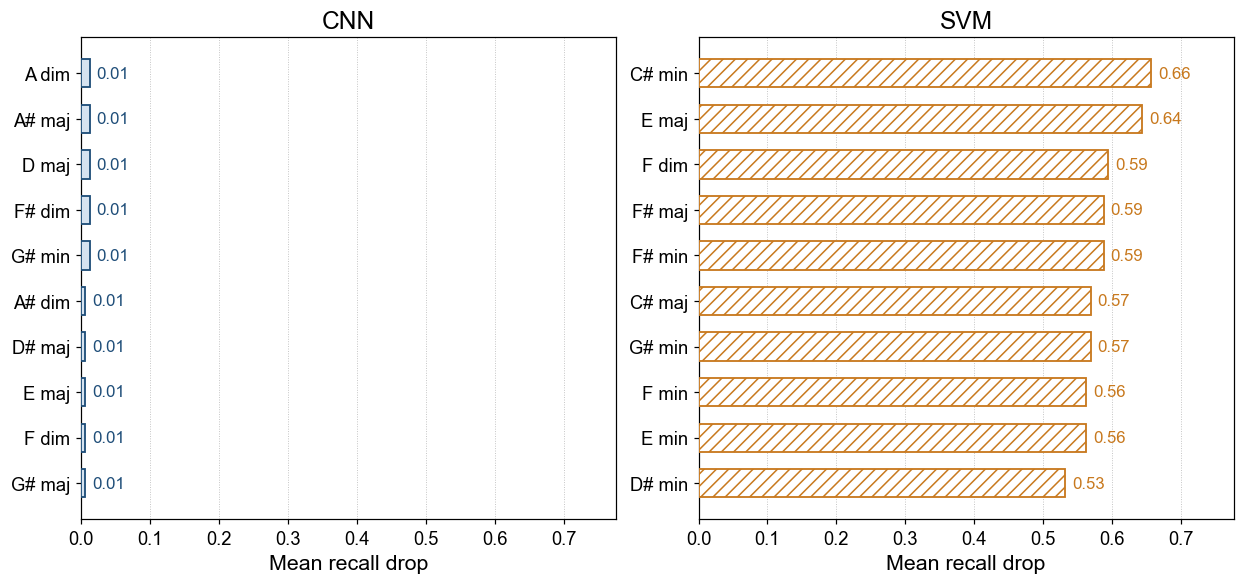

In [12]:
FILL = "#d6e3f0"
n_show = 10
cnn_top = cnn_all.head(n_show).iloc[::-1]
svm_top = svm_all.head(n_show).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2), layout="constrained", sharex=True)
for ax, top, title, edge in (
    (axes[0], cnn_top, "CNN", NAVY),
    (axes[1], svm_top, "SVM", ACCENT),
):
    y = np.arange(len(top))
    ax.barh(
        y, top["drop"], height=0.62,
        facecolor=FILL if title == "CNN" else "white",
        edgecolor=edge, linewidth=1.2, hatch="" if title == "CNN" else "///",
        zorder=3,
    )
    ax.set_yticks(y, top["class"])
    ax.set_xlabel("Mean recall drop")
    ax.set_title(title)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    for yi, v in zip(y, top["drop"]):
        ax.text(v + 0.01, yi, f"{v:.2f}", va="center", fontsize=11, color=edge)
    ax.set_xlim(0, max(cnn_all["drop"].max(), svm_all["drop"].max()) + 0.12)
plt.show()

CNN’s noise tax is a **few specific chords**, not a quality wipe. Across A1–B2 the largest mean drops are **C♯ dim (0.34)**, **A♯ min (0.32)**, then C maj / B maj / A♯ maj (~0.23–0.24). Those five lose recall on all four sets. **D maj** is the worst *absolute* noise recall (0.06) because it was already dead on A2/B2; the drop ranking hides that.

SVM’s tax is **broader and heavier**. Mean drops of 0.53–0.66 hit **C♯ min, E maj, F dim, F♯ min, F♯ maj**. Lowest noise recall is **B min (0.01)** and **G min (0.03)** — classes that were fine on recorded A1 and then collapse. By quality, SVM minors drop 0.45 and majors 0.42; CNN stays 0.10–0.13 on every quality.

Per set: CNN’s top hits rotate (D♯ dim / D min on A1, A♯ min on A2, D maj / C maj / D dim on B1, C♯ dim / A♯ min on B2). SVM repeatedly kills **minors and F♯/B-family** chords (B min, G min, F♯ min/maj, C♯ min).